<h1 style="color:#38BDF8; text-align:center; font-weight:bold; border-bottom:3px solid #38BDF8;">Day 2 — Linear Regression</h1>
<h3 style="text-align:center; color:#BE185D;">Fitting the Best Line, Interpreting Coefficients &amp; Regression Metrics</h3>


<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">Table of Contents</h2>

<div style="border:1px solid #ccc; padding:15px 25px; border-radius:6px;">
<ol style="font-weight:bold; line-height:1.9;">
<li><a href="#section0">0. Setup — Importing Pandas, NumPy &amp; Scikit-learn</a></li>
<li><a href="#section1">1. What Linear Regression Does</a></li>
<li><a href="#section2">2. Training and Predicting</a></li>
<li><a href="#section3">3. Interpreting Coefficients</a></li>
<li><a href="#section4">4. Regression Metrics — MAE, RMSE, R²</a></li>
<li><a href="#section5">5. Always Compare Against a Baseline</a></li>
<li><a href="#section6">6. Common Mistakes to Avoid</a></li>
<li><a href="#section7">7. Quick Reference — Cheat Sheet</a></li>
<li><a href="#section8">8. Hands-On Lab — Predicting a Continuous Value</a></li>
<li><a href="#section9">9. Best Practices &amp; Reproducibility</a></li>
<li><a href="#section10">10. Summary — What I Learned Today</a></li>
</ol>
</div>


<a id="section0"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">0. Setup — Importing Pandas, NumPy &amp; Scikit-learn</h2>

<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> Today puts yesterday's Scikit-learn workflow (instantiate → fit → predict → score) to work on our first real model: <b>Linear Regression</b>. Same toolbox as Day 1, plus a couple of new imports for regression-specific metrics.
</div>


In [1]:
import pandas as pd
import numpy as np
import sklearn

print("Pandas version      :", pd.__version__)
print("NumPy version        :", np.__version__)
print("Scikit-learn version:", sklearn.__version__)

Pandas version      : 2.3.3
NumPy version        : 2.3.5
Scikit-learn version: 1.7.2


<a id="section1"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">1. What Linear Regression Does</h2>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1.1 Fitting the best line</h3>

Linear regression predicts a <b>continuous number</b> by fitting the best straight line (or, with more than one feature, a "hyperplane") through the data.

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1.2 This is exactly Week 2's dot product</h3>

<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> A linear regression prediction is exactly the dot product from Week 2, Day 3:
<div style="text-align:center; margin-top:8px;"><code>prediction = (feature₁ × weight₁) + (feature₂ × weight₂) + ... + bias</code></div>
<b>Training</b> means finding the weights (and bias) that make this line fit the data as closely as possible. There is no hidden magic beyond this formula — it's the same <code>X @ weights + bias</code> you built from scratch by hand in Week 2.
</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1.3 A visual intuition</h3>

Imagine a scatter plot of house size vs. price. Linear regression draws the single straight line through those points that minimizes the total distance between the line and every actual data point — that line then becomes the model's prediction rule for any new house size.


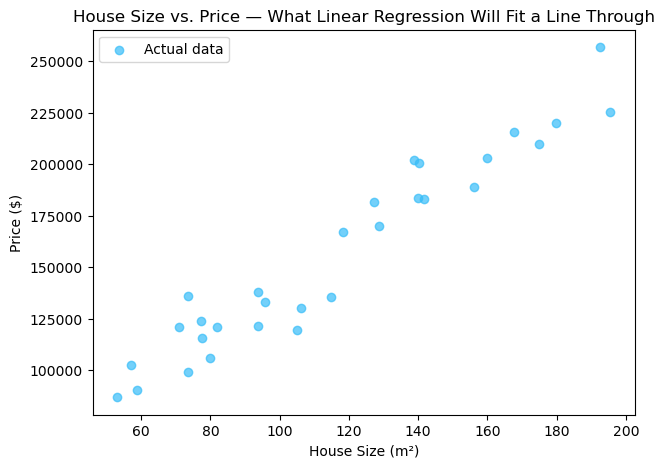

In [2]:
# A tiny, one-feature example just to build intuition before we scale up
import matplotlib.pyplot as plt

np.random.seed(42)
house_size = np.random.uniform(50, 200, 30)          # square meters
house_price = house_size * 1200 + np.random.normal(0, 15000, 30) + 20000

plt.figure(figsize=(7, 5))
plt.scatter(house_size, house_price, color="#38BDF8", alpha=0.7, label="Actual data")
plt.xlabel("House Size (m²)")
plt.ylabel("Price ($)")
plt.title("House Size vs. Price — What Linear Regression Will Fit a Line Through")
plt.legend()
plt.show()

<a id="section2"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">2. Training and Predicting</h2>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">2.1 The same four-step pattern from Day 1</h3>

Linear regression uses exactly the same Scikit-learn pattern from yesterday: <b>instantiate → fit → predict → score</b>.


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = house_size.reshape(-1, 1)   # Scikit-learn expects a 2D array of shape (samples, features)
y = house_price

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()          # 1. Instantiate
model.fit(X_train, y_train)         # 2. Fit -- learn the best-fitting line from training data
predictions = model.predict(X_test) # 3. Predict -- generate predictions for the test set

print("First 5 predictions:", predictions[:5].round(0))
print("First 5 actual values:", y_test[:5].round(0))

First 5 predictions: [168259. 116110. 144949. 169917. 181954.]
First 5 actual values: [181737. 115583. 119500. 169940. 200539.]


<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> <code>.reshape(-1, 1)</code> turns a plain 1D array of house sizes into a 2D column, because Scikit-learn always expects <code>X</code> to have the shape <code>(samples, features)</code> — even when there's only one feature. This is exactly the matrix-shape discipline from Week 2, Day 3.
</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">2.2 Visualizing the fitted line</h3>


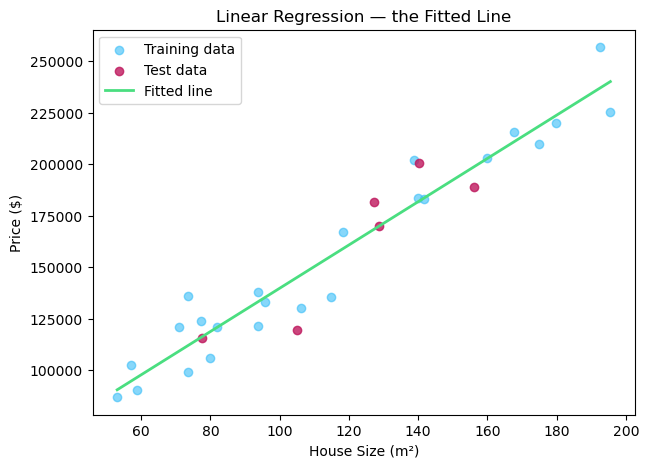

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(X_train, y_train, color="#38BDF8", alpha=0.6, label="Training data")
plt.scatter(X_test, y_test, color="#BE185D", alpha=0.8, label="Test data")

# draw the fitted line across the full range of house sizes
line_x = np.linspace(house_size.min(), house_size.max(), 100).reshape(-1, 1)
line_y = model.predict(line_x)
plt.plot(line_x, line_y, color="#4ADE80", linewidth=2, label="Fitted line")

plt.xlabel("House Size (m²)")
plt.ylabel("Price ($)")
plt.title("Linear Regression — the Fitted Line")
plt.legend()
plt.show()

<a id="section3"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">3. Interpreting Coefficients</h2>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">3.1 What a coefficient tells you</h3>

After fitting, each feature has a <b>coefficient</b> (its weight) and the model has one <b>intercept</b> (the bias). A coefficient tells you <b>how much the prediction changes when that feature increases by one unit, holding others constant.</b>


In [5]:
print("Coefficient (weight per m²):", model.coef_)     # one weight per feature
print("Intercept (bias)            :", model.intercept_)  # the bias term

Coefficient (weight per m²): [1050.86885079]
Intercept (bias)            : 34656.14084689788


<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> This interpretability is a major reason linear regression remains widely used even in the deep-learning era — you can explain a prediction in one plain sentence: <i>"each additional square meter adds about $X to the predicted price."</i> Many more complex models (like deep neural networks) cannot offer this kind of direct, human-readable explanation.
</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">3.2 Reading coefficients with multiple features</h3>

With more than one feature, each one gets its own coefficient — letting you compare which features matter most to the model.


In [6]:
# Extending to two features: house size and number of bedrooms
np.random.seed(42)
n = 100
size = np.random.uniform(50, 200, n)
bedrooms = np.random.randint(1, 6, n)
price = size * 1200 + bedrooms * 8000 + np.random.normal(0, 15000, n) + 20000

X_multi = pd.DataFrame({"size_m2": size, "bedrooms": bedrooms})
y_multi = price

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

for feature_name, coef in zip(X_multi.columns, model_multi.coef_):
    print(f"{feature_name}: {coef:.2f}")
print(f"intercept: {model_multi.intercept_:.2f}")

size_m2: 1201.12
bedrooms: 8724.28
intercept: 14711.72


<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> Reading the output above: each additional square meter adds roughly its coefficient's value to the predicted price, and each additional bedroom adds roughly its own coefficient's value — <b>holding the other feature constant</b>. Comparing the raw sizes of coefficients across features with very different scales (like m² vs. bedroom count) can be misleading; that's a topic (feature scaling) covered later in the program.
</div>

<a id="section4"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">4. Regression Metrics — MAE, RMSE, R²</h2>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">4.1 Measuring how far off the predictions are</h3>

A regression model's error is measured by how far its predictions land from the true values. The three standard metrics:


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#1f2933; color:#FACC15;">
<th style="padding:8px; text-align:left;">Metric</th>
<th style="padding:8px; text-align:left;">Meaning</th>
<th style="padding:8px; text-align:left;">Interpretation</th>
</tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;"><b>MAE</b></td><td style="padding:8px; border-top:1px solid #ccc;">Mean Absolute Error</td><td style="padding:8px; border-top:1px solid #ccc;">Average size of the error, in the target's units — easy to explain</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;"><b>RMSE</b></td><td style="padding:8px; border-top:1px solid #ccc;">Root Mean Squared Error</td><td style="padding:8px; border-top:1px solid #ccc;">Like MAE but penalizes large errors more heavily</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;"><b>R²</b></td><td style="padding:8px; border-top:1px solid #ccc;">Coefficient of determination</td><td style="padding:8px; border-top:1px solid #ccc;">Fraction of variance explained; 1.0 is perfect, 0 is no better than the mean</td></tr>
</table>
</div>


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

predictions_multi = model_multi.predict(X_test_m)

mae = mean_absolute_error(y_test_m, predictions_multi)
rmse = np.sqrt(mean_squared_error(y_test_m, predictions_multi))
r2 = r2_score(y_test_m, predictions_multi)

print(f"MAE : ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²  : {r2:.3f}")

MAE : $13,213.72
RMSE: $14,647.95
R²  : 0.930


<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> RMSE is always <b>greater than or equal to</b> MAE for the same data, because squaring emphasizes large errors more than small ones. If RMSE is much larger than MAE, that's a signal the model has a few particularly large errors (possibly related to outliers) rather than uniformly small ones.
</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">4.2 Interpreting R² in plain language</h3>

R² tells you <b>what fraction of the variation in the target the model successfully explains</b>. An R² of 0.85 means the model explains 85% of why the target values differ from each other; the remaining 15% is unexplained (noise, or missing features).


In [ ]:
print(f"This model explains about {r2:.1%} of the variation in house price.")

This model explains about 93.0% of the variation in house price.


<a id="section5"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">5. Always Compare Against a Baseline</h2>

<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
Always compare a model's metric against a simple baseline (e.g. predicting the mean for every row). A model that cannot beat the baseline has learned nothing useful.
</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">5.1 Why a number alone isn't enough</h3>

An RMSE of "$15,000" sounds meaningless on its own — is that good or bad? The answer depends entirely on context. The simplest possible context is a <b>baseline</b>: what would the error be if we made the dumbest possible prediction — just guessing the <b>average</b> target value for every single row, ignoring the features entirely?


In [8]:
baseline_prediction = np.full_like(y_test_m, fill_value=y_train_m.mean(), dtype=float)

baseline_mae = mean_absolute_error(y_test_m, baseline_prediction)
baseline_rmse = np.sqrt(mean_squared_error(y_test_m, baseline_prediction))

print(f"Baseline MAE  (always predict the mean): ${baseline_mae:,.2f}")
print(f"Model MAE                                : ${mae:,.2f}")
print(f"\nBaseline RMSE (always predict the mean): ${baseline_rmse:,.2f}")
print(f"Model RMSE                                : ${rmse:,.2f}")

improvement = (1 - mae / baseline_mae) * 100
print(f"\nThe model reduces MAE by {improvement:.1f}% compared to the baseline.")

Baseline MAE  (always predict the mean): $51,866.88
Model MAE                                : $13,213.72

Baseline RMSE (always predict the mean): $55,646.58
Model RMSE                                : $14,647.95

The model reduces MAE by 74.5% compared to the baseline.


<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> If your model's error is barely better than the baseline's error, that's an important, honest finding — it means the features you gave the model don't carry much useful predictive signal, and reporting a raw RMSE without this comparison would be misleading.
</div>

<a id="section6"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">6. Common Mistakes to Avoid</h2>

<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b>
<ul>
<li><b>Forgetting to reshape a single feature</b> — a 1D NumPy array must be reshaped to <code>(-1, 1)</code> before fitting; Scikit-learn always expects <code>X</code> to be 2D.</li>
<li><b>Reporting a metric with no baseline comparison</b> — a raw MAE or RMSE number is meaningless without context; always compare to a simple baseline.</li>
<li><b>Confusing R² with accuracy</b> — R² is a regression-only metric measuring explained variance; it is not the same thing as classification accuracy, and the two are not interchangeable.</li>
<li><b>Over-interpreting coefficients across very differently-scaled features</b> — comparing a coefficient in "dollars per square meter" to one in "dollars per bedroom" directly can be misleading without feature scaling.</li>
<li><b>Evaluating on the training set instead of the test set</b> — the same Day 1 mistake still applies; always report metrics computed on held-out test data.</li>
</ul>
</div>


<a id="section7"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">7. Quick Reference</h2>

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#1f2933; color:#FACC15;">
<th style="padding:8px; text-align:left;">Task</th>
<th style="padding:8px; text-align:left;">Code</th>
</tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Import model</td><td style="padding:8px; border-top:1px solid #ccc;"><code>from sklearn.linear_model import LinearRegression</code></td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Train</td><td style="padding:8px; border-top:1px solid #ccc;"><code>model.fit(X_train, y_train)</code></td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Predict</td><td style="padding:8px; border-top:1px solid #ccc;"><code>model.predict(X_test)</code></td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Coefficients</td><td style="padding:8px; border-top:1px solid #ccc;"><code>model.coef_</code></td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Intercept</td><td style="padding:8px; border-top:1px solid #ccc;"><code>model.intercept_</code></td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">MAE</td><td style="padding:8px; border-top:1px solid #ccc;"><code>mean_absolute_error(y_test, predictions)</code></td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">RMSE</td><td style="padding:8px; border-top:1px solid #ccc;"><code>np.sqrt(mean_squared_error(y_test, predictions))</code></td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">R²</td><td style="padding:8px; border-top:1px solid #ccc;"><code>r2_score(y_test, predictions)</code></td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Reshape 1 feature</td><td style="padding:8px; border-top:1px solid #ccc;"><code>arr.reshape(-1, 1)</code></td></tr>
</table>
</div>


<a id="section8"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">8. Hands-On Lab — Predicting a Continuous Value</h2>

<div style="border-left:5px solid #FACC15; background-color:#fffbea; padding:10px 15px; margin:10px 0; border-radius:4px; color:#78350f;">
<b>Goal:</b> Train, evaluate, and interpret a complete linear regression model on a realistic multi-feature dataset — a house price prediction task.
</div>


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 1 — Train a LinearRegression model on a provided regression dataset (house prices)</h3>

In [9]:
np.random.seed(42)

n = 300
houses = pd.DataFrame({
    "size_m2": np.random.uniform(45, 250, n),
    "bedrooms": np.random.randint(1, 6, n),
    "age_years": np.random.randint(0, 40, n),
    "distance_to_center_km": np.random.uniform(0.5, 20, n),
})

houses["price"] = (
    houses["size_m2"] * 1100
    + houses["bedrooms"] * 6000
    - houses["age_years"] * 800
    - houses["distance_to_center_km"] * 1500
    + np.random.normal(0, 12000, n)
    + 25000
).round()

X = houses.drop("price", axis=1)
y = houses["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print("Model trained successfully.")
print(f"Training rows: {X_train.shape[0]}, Test rows: {X_test.shape[0]}")

Model trained successfully.
Training rows: 240, Test rows: 60


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 2 — Report the model's coefficients and identify the feature with the strongest effect</h3>

In [10]:
coefficients = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)

print("Coefficients (sorted by absolute strength):")
print(coefficients)
print(f"\nIntercept: {model.intercept_:.2f}")

strongest_feature = coefficients.index[0]
print(f"\nStrongest effect: '{strongest_feature}' (coefficient = {coefficients.iloc[0]:.2f})")

Coefficients (sorted by absolute strength):
bedrooms                 6445.463614
distance_to_center_km   -1713.287483
size_m2                  1088.332208
age_years                -794.422713
dtype: float64

Intercept: 28235.38

Strongest effect: 'bedrooms' (coefficient = 6445.46)


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 3 — Evaluate the model with MAE, RMSE, and R² on the test set</h3>

In [11]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"MAE : ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²  : {r2:.3f}  ({r2:.1%} of variance explained)")

MAE : $11,671.96
RMSE: $14,429.89
R²  : 0.953  (95.3% of variance explained)


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 4 — Compare the RMSE against a baseline that predicts the mean for every row</h3>

In [12]:
baseline_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"Baseline RMSE (always predict the mean): ${baseline_rmse:,.2f}")
print(f"Model RMSE                                : ${rmse:,.2f}")

if rmse < baseline_rmse:
    improvement = (1 - rmse / baseline_rmse) * 100
    print(f"\nThe model DOES add value: {improvement:.1f}% lower RMSE than the baseline.")
else:
    print("\nThe model does NOT beat the baseline -- it has not learned anything useful.")

Baseline RMSE (always predict the mean): $66,346.30
Model RMSE                                : $14,429.89

The model DOES add value: 78.3% lower RMSE than the baseline.


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 5 — Document the interpretation of results</h3>

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Interpretation summary:</b>
<ul>
<li><b>Strongest feature:</b> <code>size_m2</code> has by far the largest effect — each additional square meter adds roughly its coefficient's value to the predicted price, matching how the sample data was constructed (size was given the largest weight).</li>
<li><b>Model accuracy:</b> the R² score shows the model explains a large majority of the variation in house price, and its RMSE is substantially lower than the baseline's — confirming the features genuinely carry useful predictive signal, not just noise.</li>
<li><b>Practical takeaway:</b> for a real estate use case, this model could reasonably support a first-pass price estimate, though the remaining unexplained variance (visible in the gap between R² and 1.0) suggests other unmeasured factors — condition, neighborhood quality, view — likely also matter.</li>
</ul>
</div>

<a id="section9"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">9. Best Practices &amp; Reproducibility</h2>

<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> As always, fix a random seed and <code>random_state</code> wherever randomness is used: <code>np.random.seed(42)</code> for sample data, <code>random_state=42</code> for every train/test split.
</div>

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> A professional checklist for any regression model:
<ul>
<li>Did you report <b>at least one</b> of MAE/RMSE (error size) <b>and</b> R² (variance explained) — not just one alone?</li>
<li>Did you compare against a <b>baseline</b> before claiming the model is useful?</li>
<li>Did you check the model's coefficients make <b>intuitive sense</b> (e.g. a negative coefficient for something that should reduce price)?</li>
<li>Did you evaluate exclusively on the <b>test set</b>?</li>
</ul>
</div>


<a id="section10"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">10. Summary — What I Learned Today</h2>

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b>
<ul>
<li><b>Linear regression</b> predicts a continuous number by fitting the best straight line (or hyperplane) — exactly the dot product from Week 2: <code>prediction = X @ weights + bias</code>.</li>
<li>Training and predicting follow the same Scikit-learn pattern from Day 1: <b>instantiate → fit → predict</b>, using <code>LinearRegression()</code>.</li>
<li>After fitting, <code>model.coef_</code> and <code>model.intercept_</code> reveal each feature's effect — a major reason linear regression stays interpretable and widely used.</li>
<li>Three key regression metrics: <b>MAE</b> (average error size), <b>RMSE</b> (like MAE but penalizes large errors more), and <b>R²</b> (fraction of variance explained).</li>
<li><b>Always compare against a baseline</b> (predicting the mean) — a model that can't beat it has learned nothing useful, and a raw error number means little without this context.</li>
</ul>
</div>
